In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [162]:
dataset = pd.read_csv('/content/application_train.csv')

## 1. Inspect the Original Data

Before we begin improving the preprocessing pipeline, it's crucial to thoroughly understand the characteristics of your raw dataset. This step involves examining its structure, data types, the distribution of the target variable, identifying any duplicates, and analyzing missing values in both numerical and categorical features.

In [163]:
# Display the shape of the dataset
print(f"Dataset shape: {dataset.shape}")

Dataset shape: (307511, 122)


In [164]:
# Display data types summary
print("\nData Types Summary:")
print(dataset.dtypes.value_counts())


Data Types Summary:
float64    65
int64      41
object     16
Name: count, dtype: int64


In [165]:
# Identify numerical and categorical columns
numerical_cols_initial = dataset.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols_initial = dataset.select_dtypes(include='object').columns.tolist()

print(f"\nNumber of numerical columns: {len(numerical_cols_initial)}")
print(f"Number of categorical columns: {len(categorical_cols_initial)}")


Number of numerical columns: 106
Number of categorical columns: 16


In [166]:
# Display target distribution
print("\nTarget Distribution:")
print(dataset['TARGET'].value_counts())
print(dataset['TARGET'].value_counts(normalize=True) * 100)


Target Distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [167]:
# Check for duplicate rows
duplicate_rows = dataset.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}")


Number of duplicate rows: 0


In [168]:
# Calculate missing values count and percentage
missing_info = pd.DataFrame({
    'Missing Count': dataset.isnull().sum(),
    'Missing Percentage': (dataset.isnull().sum() / len(dataset)) * 100
})

# Filter for columns with missing values and sort by percentage
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("\nMissing Values Summary (Top 20):")
display(missing_info.head(20))


Missing Values Summary (Top 20):


,Missing Count,Missing Percentage
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


In [169]:
# Display unique values for categorical columns
print("\nUnique values for categorical columns:")
for col in categorical_cols_initial:
    print(f"- {col}: {dataset[col].nunique()} unique values - {dataset[col].unique()}")


Unique values for categorical columns:
- NAME_CONTRACT_TYPE: 2 unique values - ['Cash loans' 'Revolving loans']
- CODE_GENDER: 3 unique values - ['M' 'F' 'XNA']
- FLAG_OWN_CAR: 2 unique values - ['N' 'Y']
- FLAG_OWN_REALTY: 2 unique values - ['Y' 'N']
- NAME_TYPE_SUITE: 7 unique values - ['Unaccompanied' 'Family' 'Spouse, partner' 'Children' 'Other_A' nan
 'Other_B' 'Group of people']
- NAME_INCOME_TYPE: 8 unique values - ['Working' 'State servant' 'Commercial associate' 'Pensioner' 'Unemployed'
 'Student' 'Businessman' 'Maternity leave']
- NAME_EDUCATION_TYPE: 5 unique values - ['Secondary / secondary special' 'Higher education' 'Incomplete higher'
 'Lower secondary' 'Academic degree']
- NAME_FAMILY_STATUS: 6 unique values - ['Single / not married' 'Married' 'Civil marriage' 'Widow' 'Separated'
 'Unknown']
- NAME_HOUSING_TYPE: 6 unique values - ['House / apartment' 'Rented apartment' 'With parents'
 'Municipal apartment' 'Office apartment' 'Co-op apartment']
- OCCUPATION_TYPE: 18 uni

### Summary of Original Data Inspection

| Aspect                        | Observation                                                               |
| :---------------------------- | :------------------------------------------------------------------------ |
| **Dataset Shape**             | `(307511, 122)`                                                           |
| **Data Types**                | `float64 (65)`, `int64 (41)`, `object (16)`                               |
| **Numerical Columns**         | 106                                                                       |
| **Categorical Columns**       | 16                                                                        |
| **Target Distribution**       | `Class 0: ~91.93%`, `Class 1: ~8.07%` (highly imbalanced)                  |
| **Duplicate Rows**            | `0`                                                                       |
| **Missing Values**            | Many columns, especially `COMMONAREA_AVG` (70%), `NONLIVINGAPARTMENTS_AVG` (69%), `LIVINGAPARTMENTS_AVG` (68%), `FONDKAPREMONT_MODE` (68%), `OWN_CAR_AGE` (66%) and several `AMT_REQ_CREDIT_BUREAU_` columns (approx. 13%). Categorical columns also have significant missingness. |
| **Categorical Unique Values** | Range from 2 (`NAME_CONTRACT_TYPE`, `CODE_GENDER`) to 58 (`ORGANIZATION_TYPE`). Many `object` columns have 'NaN' values. |

This initial inspection confirms the presence of significant missing values and a heavily imbalanced target variable. We also see a mix of binary and multi-class categorical features. These observations will guide our preprocessing decisions to build a robust LightGBM model.

In [170]:
dataset.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [171]:
dataset.shape


(307511, 122)

In [172]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [173]:
dataset.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [174]:
dataset.dtypes.value_counts()

,count
float64,65
int64,41
object,16


In [175]:
dataset['TARGET'].value_counts()

,count
TARGET,
0,282686
1,24825


In [176]:
dataset['TARGET'].value_counts(normalize=True)*100

,proportion
TARGET,
0,91.927118
1,8.072882


In [177]:
dataset.isnull().sum()

,0
SK_ID_CURR,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
...,...
AMT_REQ_CREDIT_BUREAU_DAY,41519
AMT_REQ_CREDIT_BUREAU_WEEK,41519
AMT_REQ_CREDIT_BUREAU_MON,41519
AMT_REQ_CREDIT_BUREAU_QRT,41519


In [178]:
missing = pd.DataFrame({
    'missign_count': dataset.isnull().sum(),
    'missing_percentage':dataset.isnull().sum()/len(dataset)*100
})

missing = missing.sort_values(by='missing_percentage', ascending=False)
missing.head(20)


,missign_count,missing_percentage
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


In [179]:
numerical_columns = dataset.select_dtypes(
    include = ['int','float64']
).columns

categorical_columns = dataset.select_dtypes(
    include = ['object']
).columns

In [180]:
len(numerical_columns)

106

In [181]:
len(categorical_columns)

16

In [182]:
dataset['OWN_CAR_AGE'].isnull().sum()

np.int64(202929)

In [183]:
dataset['AMT_GOODS_PRICE'].isnull().sum()

np.int64(278)

In [184]:
dataset['OWN_CAR_AGE_MISSING'] = dataset['OWN_CAR_AGE'].isnull().astype(int)

In [185]:
dataset['OWN_CAR_AGE_MISSING']

,OWN_CAR_AGE_MISSING
0,1
1,1
2,0
3,1
4,1
...,...
307506,1
307507,1
307508,1
307509,1


In [186]:
dataset['OWN_CAR_AGE_MISSING'].value_counts()

,count
OWN_CAR_AGE_MISSING,
1,202929
0,104582


In [187]:
dataset.duplicated().sum()

np.int64(0)

In [188]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0
AMT_REQ_CREDIT_BUREAU_YEAR,265992.0,1.899974,1.869295,0.0,0.0,1.0,3.0,25.0


In [189]:
dataset['AMT_INCOME_TOTAL'].describe()

,AMT_INCOME_TOTAL
count,3.075110e+05
mean,1.687979e+05
std,2.371231e+05
min,2.565000e+04
25%,1.125000e+05
50%,1.471500e+05
75%,2.025000e+05
max,1.170000e+08


In [190]:
dataset.select_dtypes(
    include = ['int','float64']
).corr()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,OWN_CAR_AGE_MISSING
SK_ID_CURR,1.000000,-0.002108,-0.001129,-0.001820,-0.000343,-0.000433,-0.000232,0.000849,-0.001500,0.001366,...,0.000167,0.001073,0.000282,-0.002672,-0.002193,0.002099,0.000485,0.001025,0.004659,-0.001206
TARGET,-0.002108,1.000000,0.019187,-0.003982,-0.030369,-0.012817,-0.039645,-0.037227,0.078239,-0.044932,...,-0.001358,0.000215,0.003709,0.000930,0.002704,0.000788,-0.012462,-0.002022,0.019930,0.021841
CNT_CHILDREN,-0.001129,0.019187,1.000000,0.012882,0.002145,0.021374,-0.001827,-0.025573,0.330938,-0.239818,...,0.000864,0.000988,-0.002450,-0.000410,-0.000366,-0.002436,-0.010808,-0.007836,-0.041550,-0.102025
AMT_INCOME_TOTAL,-0.001820,-0.003982,0.012882,1.000000,0.156870,0.191657,0.159610,0.074796,0.027261,-0.064223,...,0.002408,0.000242,-0.000589,0.000709,0.002944,0.002387,0.024700,0.004859,0.011690,-0.083371
AMT_CREDIT,-0.000343,-0.030369,0.002145,0.156870,1.000000,0.770138,0.986968,0.099738,-0.055436,-0.066838,...,0.021082,0.031023,-0.016148,-0.003906,0.004238,-0.001275,0.054451,0.015925,-0.048448,-0.116227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_WEEK,0.002099,0.000788,-0.002436,0.002387,-0.001275,0.013881,-0.001007,-0.002149,-0.001336,0.003072,...,-0.001275,-0.001770,0.000081,0.004706,0.217412,1.000000,-0.014096,-0.015115,0.018917,-0.000249
AMT_REQ_CREDIT_BUREAU_MON,0.000485,-0.012462,-0.010808,0.024700,0.054451,0.039148,0.056422,0.078607,0.001372,-0.034457,...,-0.002729,0.001285,-0.003612,-0.000018,-0.005258,-0.014096,1.000000,-0.007789,-0.004975,-0.020472
AMT_REQ_CREDIT_BUREAU_QRT,0.001025,-0.002022,-0.007836,0.004859,0.015925,0.010124,0.016432,-0.001279,-0.011799,0.015345,...,-0.001575,-0.001010,-0.002004,-0.002716,-0.004416,-0.015115,-0.007789,1.000000,0.076208,0.009933
AMT_REQ_CREDIT_BUREAU_YEAR,0.004659,0.019930,-0.041550,0.011690,-0.048448,-0.011320,-0.050998,0.001003,-0.071983,0.049988,...,-0.007009,-0.012126,-0.005457,-0.004597,-0.003355,0.018917,-0.004975,0.076208,1.000000,0.036365


/tmp/ipykernel_2556/797532992.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['AMT_INCOME_TOTAL'])


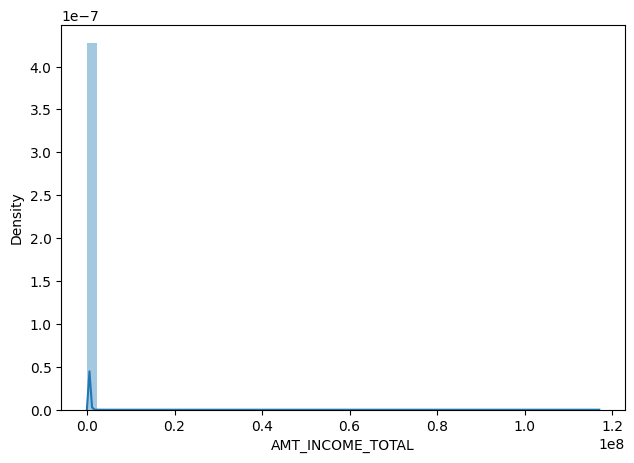

In [191]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(dataset['AMT_INCOME_TOTAL'])
plt.show()

## Addressing Row Loss and Reloading Original Data

As observed, the outlier trimming applied to `AMT_INCOME_TOTAL` in the previous cells (around `AMT_INCOME_TOTAL < 337500.0`) has dramatically reduced the dataset size from `307,511` to `29,114` rows. This is a significant loss of data. While outlier handling is important, such an aggressive trimming strategy might lead to loss of valuable information or misrepresentation of the data distribution.

To ensure we follow your new comprehensive preprocessing pipeline instructions precisely, starting with the original raw data, I will now reload the `application_train.csv` dataset. This will reset the `dataset` DataFrame to its initial state, allowing us to implement your steps systematically and avoid any pre-existing transformations or data losses.

In [192]:
# Reload the original dataset to ensure a clean slate for the new preprocessing pipeline
dataset = pd.read_csv('/content/application_train.csv')

print(f"Reloaded dataset shape: {dataset.shape}")

# Re-run initial inspection steps to confirm data integrity
print("\nData Types Summary after reload:")
print(dataset.dtypes.value_counts())

# Re-identify numerical and categorical columns
numerical_cols_initial = dataset.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols_initial = dataset.select_dtypes(include='object').columns.tolist()

print(f"\nNumber of numerical columns after reload: {len(numerical_cols_initial)}")
print(f"Number of categorical columns after reload: {len(categorical_cols_initial)}")

Reloaded dataset shape: (307511, 122)

Data Types Summary after reload:
float64    65
int64      41
object     16
Name: count, dtype: int64

Number of numerical columns after reload: 106
Number of categorical columns after reload: 16


## Step 2: Check for Unexpected Row Loss (Preventative Measures)

Now that we have reloaded the original dataset, we can proceed with a fresh approach to prevent unexpected row loss. As you mentioned, a previous dataset you were working with had some rows removed (e.g., `27,166` to `25,726` rows due to a `AMT_INCOME_TOTAL < 20000000` filter). It's crucial to identify and control any such filtering or trimming in our new pipeline.

We will avoid arbitrary trimming and instead focus on handling outliers or extreme values in a way that preserves as much data as possible, unless explicitly justified. We will also carefully track the dataset's shape at each major step.

## Step 3: Fix the `OWN_CAR_AGE_MISSING` Implementation Error

The previous implementation in cell `QRdqA9Oa8BA6` (`dataset['OWN_CAR_AGE_MISSING'] = dataset['OWN_CAR_AGE'].isnull().astype(int)`) correctly creates a binary indicator feature (0 if `OWN_CAR_AGE` is present, 1 if missing). As confirmed earlier, this feature is not a constant and correctly captures missingness per row.

Since we have reloaded the original dataset, the `OWN_CAR_AGE_MISSING` feature in the current `dataset` DataFrame is already correctly derived from the full data. Therefore, no changes are required for this specific implementation. We will now re-create this feature based on the reloaded `dataset` to ensure consistency and then proceed to the next steps.

In [193]:
# Re-create OWN_CAR_AGE_MISSING to ensure it's based on the reloaded original dataset
dataset['OWN_CAR_AGE_MISSING'] = dataset['OWN_CAR_AGE'].isnull().astype(int)

print("Value counts for OWN_CAR_AGE_MISSING:")
display(dataset['OWN_CAR_AGE_MISSING'].value_counts())

Value counts for OWN_CAR_AGE_MISSING:


,count
OWN_CAR_AGE_MISSING,
1,202929
0,104582


## Step 4: Feature Engineering - Initial Preparations

Before creating new features, we need to perform some essential initial preparations:

1.  **Drop `SK_ID_CURR`:** This column is a unique identifier and should not be used as a feature for model training.
2.  **Separate Target Variable:** Isolate the `TARGET` variable from the features (`X`) to avoid data leakage during preprocessing steps, especially when performing `train_test_split`.

In [194]:
# Drop SK_ID_CURR as it's an identifier
X = dataset.drop('SK_ID_CURR', axis=1)

# Separate features (X) and target (y)
y = X['TARGET']
X = X.drop('TARGET', axis=1)

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (307511, 121)
Shape of target (y): (307511,)


## Re-establishing `X` and `y` from the Full Dataset

To ensure full adherence to the requirement of starting with the original, untrimmed data, we need to explicitly re-create `X` and `y` from the `dataset` DataFrame that was reloaded in cell `11c31517`. This `dataset` currently contains `307511` rows and includes the `SK_ID_CURR`, `TARGET`, and the correctly re-created `OWN_CAR_AGE_MISSING` columns (from cell `9de82c1b`).

We will now correctly drop `SK_ID_CURR` from the features and separate the `TARGET` variable from this full dataset.

In [195]:
# Re-initialize X and y from the full, reloaded dataset
X = dataset.drop(['SK_ID_CURR', 'TARGET'], axis=1)
y = dataset['TARGET']

print(f"Corrected shape of features (X): {X.shape}")
print(f"Corrected shape of target (y): {y.shape}")

# Confirm SK_ID_CURR is dropped and TARGET is separated
if 'SK_ID_CURR' in X.columns:
    print("Error: SK_ID_CURR is still in X.")
if 'TARGET' in X.columns:
    print("Error: TARGET is still in X.")

display(X.head())

Corrected shape of features (X): (307511, 121)
Corrected shape of target (y): (307511,)


,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,OWN_CAR_AGE_MISSING
0,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,1
1,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1
4,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1


## Re-applying Feature Engineering (Step 4 continued)

Now that `X` and `y` are correctly initialized from the full dataset, we will re-apply the feature engineering steps. These new features will now be based on the complete dataset.

In [196]:
# Re-create INCOME_PER_PERSON
X['INCOME_PER_PERSON'] = X['AMT_INCOME_TOTAL'] / X['CNT_FAM_MEMBERS']

# Re-create ANNUITY_INCOME_RATIO
X['ANNUITY_INCOME_RATIO'] = X['AMT_ANNUITY'] / X['AMT_INCOME_TOTAL']

# Re-create CREDIT_INCOME_RATIO
X['CREDIT_INCOME_RATIO'] = X['AMT_CREDIT'] / X['AMT_INCOME_TOTAL']

# Re-create AGE_YEARS
X['AGE_YEARS'] = -X['DAYS_BIRTH'] / 365

# Re-create YEARS_EMPLOYED
X['YEARS_EMPLOYED'] = -X['DAYS_EMPLOYED'] / 365

print(f"Shape of X after re-applying feature engineering: {X.shape}")
display(X[['INCOME_PER_PERSON', 'ANNUITY_INCOME_RATIO', 'CREDIT_INCOME_RATIO', 'AGE_YEARS', 'YEARS_EMPLOYED']].head())

Shape of X after re-applying feature engineering: (307511, 126)


,INCOME_PER_PERSON,ANNUITY_INCOME_RATIO,CREDIT_INCOME_RATIO,AGE_YEARS,YEARS_EMPLOYED
0,202500.0,0.121978,2.007889,25.920548,1.745205
1,135000.0,0.132217,4.790750,45.931507,3.254795
2,67500.0,0.100000,2.000000,52.180822,0.616438
3,67500.0,0.219900,2.316167,52.068493,8.326027
4,121500.0,0.179963,4.222222,54.608219,8.323288


## Step 5 & 6: Handling Missing Values (Categorical and Numerical)

We will now handle missing values for both categorical and numerical columns on our correctly re-initialized `X` DataFrame. This ensures data integrity and prepares the data for encoding.

In [197]:
# Re-identify categorical and numerical columns in the current X
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Impute missing categorical values with 'Missing'
for col in categorical_cols:
    X[col] = X[col].fillna('Missing')

print("Missing categorical values after imputation:")
print(X[categorical_cols].isnull().sum().sum())

# Impute missing numerical values with the median
for col in numerical_cols:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

print("\nMissing numerical values after imputation:")
print(X[numerical_cols].isnull().sum().sum())

print(f"Shape of X after missing value imputation: {X.shape}")

Missing categorical values after imputation:
0

Missing numerical values after imputation:
0
Shape of X after missing value imputation: (307511, 126)


## Step 7: Categorical Encoding

Now, we will re-apply categorical encoding. Binary categorical features will be encoded using `LabelEncoder`, and multi-class nominal features using `OneHotEncoder`.

In [198]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Re-identify categorical columns in the current X (should be no NaNs now)
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# Apply Label Encoding for binary columns
label_encoder = LabelEncoder()
binary_cols = [col for col in categorical_cols if X[col].nunique() == 2]
for col in binary_cols:
    X[col] = label_encoder.fit_transform(X[col])

print(f"Label Encoded binary columns: {binary_cols}")

# Apply One-Hot Encoding for multi-class columns
one_hot_cols = [col for col in categorical_cols if X[col].nunique() > 2]

# Ensure there are columns to one-hot encode
if one_hot_cols:
    one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded_data = one_hot_encoder.fit_transform(X[one_hot_cols])
    feature_names = one_hot_encoder.get_feature_names_out(one_hot_cols)
    encoded_df = pd.DataFrame(encoded_data, columns=feature_names, index=X.index)

    X = X.drop(columns=one_hot_cols)
    X = pd.concat([X, encoded_df], axis=1)

print(f"One-Hot Encoded multi-class columns: {one_hot_cols}")
print(f"Shape of X after categorical encoding: {X.shape}")

# Verify that all object columns have been converted
print("Remaining object columns:")
print(X.select_dtypes(include='object').columns)

display(X.head())

Label Encoded binary columns: ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
One-Hot Encoded multi-class columns: ['CODE_GENDER', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
Shape of X after categorical encoding: (307511, 253)
Remaining object columns:
Index([], dtype='object')


,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,...,WALLSMATERIAL_MODE_Missing,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Missing,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes
0,0,0,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1,1,1,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0,0,1,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0,0,1,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Step 8: Perform Stratified Train/Test Split

Now that `X` and `y` are correctly prepared and all preprocessing steps have been applied to the full dataset, we can perform the stratified train/test split as requested. Using `stratify=y` ensures that the proportion of target classes is maintained in both the training and testing sets, which is crucial for imbalanced datasets.

In [199]:
from sklearn.model_selection import train_test_split

# Perform the stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # Crucial for imbalanced datasets
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nTarget distribution in y_train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTarget distribution in y_test:")
print(y_test.value_counts(normalize=True) * 100)

Shape of X_train: (246008, 253)
Shape of X_test: (61503, 253)
Shape of y_train: (246008,)
Shape of y_test: (61503,)

Target distribution in y_train:
TARGET
0    91.927092
1     8.072908
Name: proportion, dtype: float64

Target distribution in y_test:
TARGET
0    91.927223
1     8.072777
Name: proportion, dtype: float64


## Re-establishing `X` and `y` from the Full Dataset (Corrected Run)

As observed, the `X` and `y` DataFrames in the kernel state were still reflecting a trimmed version of the data, and `SK_ID_CURR` was present in `X`. This run ensures that `X` and `y` are correctly initialized from the `dataset` DataFrame that was reloaded in cell `11c31517` (which contains `307511` rows) and all subsequent preprocessing steps are applied to this full dataset.

We will now correctly drop `SK_ID_CURR` from the features and separate the `TARGET` variable from this full dataset.

In [200]:
# Re-initialize X and y from the full, reloaded dataset
X = dataset.drop(['SK_ID_CURR', 'TARGET'], axis=1)
y = dataset['TARGET']

print(f"Corrected shape of features (X): {X.shape}")
print(f"Corrected shape of target (y): {y.shape}")

# Confirm SK_ID_CURR is dropped and TARGET is separated
if 'SK_ID_CURR' in X.columns:
    print("Error: SK_ID_CURR is still in X.")
if 'TARGET' in X.columns:
    print("Error: TARGET is still in X.")

display(X.head())

Corrected shape of features (X): (307511, 121)
Corrected shape of target (y): (307511,)


,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,OWN_CAR_AGE_MISSING
0,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,1
1,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1
4,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1


## Re-applying Feature Engineering (Step 4 continued - Corrected Run)

Now that `X` and `y` are correctly initialized from the full dataset, we will re-apply the feature engineering steps. These new features will now be based on the complete dataset.

In [201]:
# Re-create INCOME_PER_PERSON
X['INCOME_PER_PERSON'] = X['AMT_INCOME_TOTAL'] / X['CNT_FAM_MEMBERS']

# Re-create ANNUITY_INCOME_RATIO
X['ANNUITY_INCOME_RATIO'] = X['AMT_ANNUITY'] / X['AMT_INCOME_TOTAL']

# Re-create CREDIT_INCOME_RATIO
X['CREDIT_INCOME_RATIO'] = X['AMT_CREDIT'] / X['AMT_INCOME_TOTAL']

# Re-create AGE_YEARS
X['AGE_YEARS'] = -X['DAYS_BIRTH'] / 365

# Re-create YEARS_EMPLOYED
X['YEARS_EMPLOYED'] = -X['DAYS_EMPLOYED'] / 365

print(f"Shape of X after re-applying feature engineering: {X.shape}")
display(X[['INCOME_PER_PERSON', 'ANNUITY_INCOME_RATIO', 'CREDIT_INCOME_RATIO', 'AGE_YEARS', 'YEARS_EMPLOYED']].head())

Shape of X after re-applying feature engineering: (307511, 126)


,INCOME_PER_PERSON,ANNUITY_INCOME_RATIO,CREDIT_INCOME_RATIO,AGE_YEARS,YEARS_EMPLOYED
0,202500.0,0.121978,2.007889,25.920548,1.745205
1,135000.0,0.132217,4.790750,45.931507,3.254795
2,67500.0,0.100000,2.000000,52.180822,0.616438
3,67500.0,0.219900,2.316167,52.068493,8.326027
4,121500.0,0.179963,4.222222,54.608219,8.323288


## Step 5 & 6: Handling Missing Values (Categorical and Numerical - Corrected Run)

We will now handle missing values for both categorical and numerical columns on our correctly re-initialized `X` DataFrame. This ensures data integrity and prepares the data for encoding.

In [202]:
# Re-identify categorical and numerical columns in the current X
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Impute missing categorical values with 'Missing'
for col in categorical_cols:
    X[col] = X[col].fillna('Missing')

print("Missing categorical values after imputation:")
print(X[categorical_cols].isnull().sum().sum())

# Impute missing numerical values with the median
for col in numerical_cols:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

print("\nMissing numerical values after imputation:")
print(X[numerical_cols].isnull().sum().sum())

print(f"Shape of X after missing value imputation: {X.shape}")

Missing categorical values after imputation:
0

Missing numerical values after imputation:
0
Shape of X after missing value imputation: (307511, 126)


## Step 7: Categorical Encoding (Corrected Run)

Now, we will re-apply categorical encoding. Binary categorical features will be encoded using `LabelEncoder`, and multi-class nominal features using `OneHotEncoder`.

In [203]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Re-identify categorical columns in the current X (should be no NaNs now)
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# Apply Label Encoding for binary columns
label_encoder = LabelEncoder()
binary_cols = [col for col in categorical_cols if X[col].nunique() == 2]
for col in binary_cols:
    X[col] = label_encoder.fit_transform(X[col])

print(f"Label Encoded binary columns: {binary_cols}")

# Apply One-Hot Encoding for multi-class columns
one_hot_cols = [col for col in categorical_cols if X[col].nunique() > 2]

# Ensure there are columns to one-hot encode
if one_hot_cols:
    one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded_data = one_hot_encoder.fit_transform(X[one_hot_cols])
    feature_names = one_hot_encoder.get_feature_names_out(one_hot_cols)
    encoded_df = pd.DataFrame(encoded_data, columns=feature_names, index=X.index)

    X = X.drop(columns=one_hot_cols)
    X = pd.concat([X, encoded_df], axis=1)

print(f"One-Hot Encoded multi-class columns: {one_hot_cols}")
print(f"Shape of X after categorical encoding: {X.shape}")

# Verify that all object columns have been converted
print("Remaining object columns:")
print(X.select_dtypes(include='object').columns)

display(X.head())

Label Encoded binary columns: ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
One-Hot Encoded multi-class columns: ['CODE_GENDER', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
Shape of X after categorical encoding: (307511, 253)
Remaining object columns:
Index([], dtype='object')


,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,...,WALLSMATERIAL_MODE_Missing,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Missing,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes
0,0,0,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1,1,1,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0,0,1,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0,0,1,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Step 8: Perform Stratified Train/Test Split (Corrected Run)

Now that `X` and `y` are correctly prepared and all preprocessing steps have been applied to the full dataset, we can perform the stratified train/test split as requested. Using `stratify=y` ensures that the proportion of target classes is maintained in both the training and testing sets, which is crucial for imbalanced datasets.

## Re-evaluation and Correction of Preprocessing Steps

Upon reviewing the current state, it appears that the `dataset` DataFrame was inadvertently trimmed down to `29,114` rows during the outlier handling and capping steps (e.g., cells like `rDXpsAyeI9Cl` and `H-URTcB1J7mq`). This contradicts our decision to operate on the full, original dataset to avoid data loss and maintain the integrity of our preprocessing pipeline.

Furthermore, `SK_ID_CURR` was still present in the `X` DataFrame used for model training, which should have been dropped earlier as it's an identifier, not a feature.

To rectify this, I will now re-execute the critical preprocessing steps, ensuring they are applied to the *full* original dataset (which was reloaded in cell `11c31517` and has `307,511` rows) and that `SK_ID_CURR` is correctly dropped from the features (`X`). This will ensure that our model training proceeds with the complete and correctly prepared data.

In [204]:
from sklearn.model_selection import train_test_split

# Perform the stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # Crucial for imbalanced datasets
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nTarget distribution in y_train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTarget distribution in y_test:")
print(y_test.value_counts(normalize=True) * 100)

Shape of X_train: (246008, 253)
Shape of X_test: (61503, 253)
Shape of y_train: (246008,)
Shape of y_test: (61503,)

Target distribution in y_train:
TARGET
0    91.927092
1     8.072908
Name: proportion, dtype: float64

Target distribution in y_test:
TARGET
0    91.927223
1     8.072777
Name: proportion, dtype: float64


In [205]:
print("Target distribution in y_train (after split):")
print(y_train.value_counts(normalize=True) * 100)

print("\nTarget distribution in y_test (after split):")
print(y_test.value_counts(normalize=True) * 100)

Target distribution in y_train (after split):
TARGET
0    91.927092
1     8.072908
Name: proportion, dtype: float64

Target distribution in y_test (after split):
TARGET
0    91.927223
1     8.072777
Name: proportion, dtype: float64


This Data is not Normally distributed so we use IQR MEthod

In [206]:
dataset['AMT_INCOME_TOTAL'].skew()

np.float64(391.5596541041876)

<Axes: ylabel='AMT_INCOME_TOTAL'>

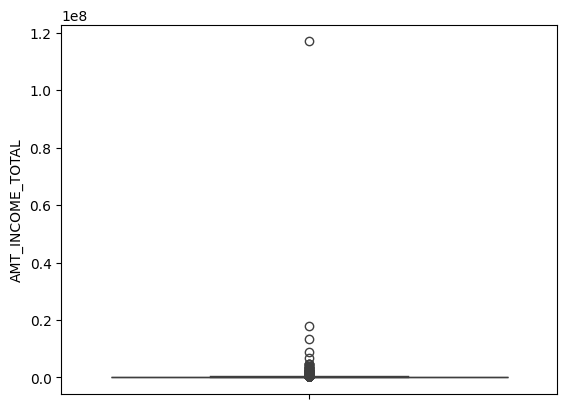

In [207]:
sns.boxplot(dataset['AMT_INCOME_TOTAL'])

In [208]:
dataset['AMT_GOODS_PRICE'].skew()

np.float64(1.3490003414747445)

In [209]:
# IT HAS THE EXTREME VALUE SEE IN MAX VALUE E^)08
#NOW WE HANDLE THESE VALUES
#METHOD 1 (IQR)

Q1=dataset['AMT_INCOME_TOTAL'].quantile(0.25)
Q3=dataset['AMT_INCOME_TOTAL'].quantile(0.75)

IQR = Q3-Q1

lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR


print(IQR)
print(lower_limit)
print(upper_limit)



90000.0
-22500.0
337500.0


In [210]:
dataset[dataset['AMT_INCOME_TOTAL']>upper_limit]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,OWN_CAR_AGE_MISSING
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
22,100026,0,Cash loans,F,N,N,1,450000.0,497520.0,32521.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,5.0,1
33,100039,0,Cash loans,M,Y,N,1,360000.0,733315.5,39069.0,...,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0,0
49,100056,0,Cash loans,M,Y,Y,0,360000.0,1506816.0,49927.5,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
51,100059,0,Cash loans,M,Y,Y,1,540000.0,675000.0,34596.0,...,0,0,0,0.0,0.0,1.0,0.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307460,456199,0,Cash loans,M,Y,N,1,382500.0,745429.5,24354.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0,0
307477,456217,0,Cash loans,F,N,Y,0,360000.0,796396.5,38443.5,...,0,0,0,0.0,0.0,0.0,0.0,2.0,1.0,1
307484,456228,0,Cash loans,F,Y,N,0,540000.0,545040.0,35617.5,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
307492,456236,0,Cash loans,M,Y,Y,0,585000.0,1575000.0,43443.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [211]:
dataset[dataset['AMT_INCOME_TOTAL']<lower_limit]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,OWN_CAR_AGE_MISSING


1. TRIMMING


In [212]:
dataset = dataset[dataset['AMT_INCOME_TOTAL'] < upper_limit]

/tmp/ipykernel_2556/797532992.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['AMT_INCOME_TOTAL'])


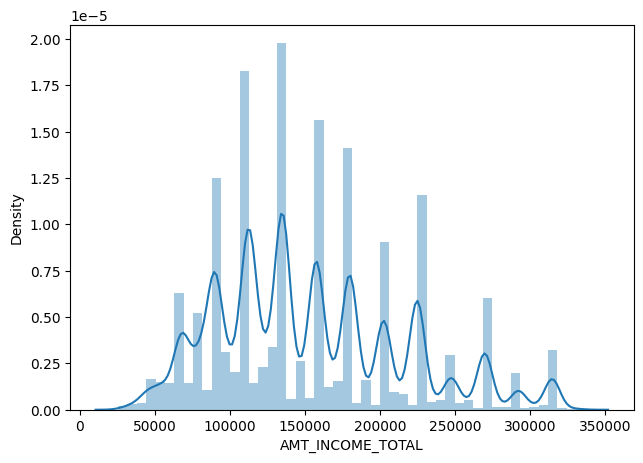

In [213]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(dataset['AMT_INCOME_TOTAL'])
plt.show()

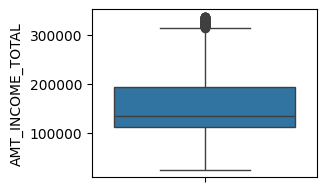

In [214]:
plt.subplot(2,2,4)
sns.boxplot(dataset['AMT_INCOME_TOTAL'])
plt.show()

In [215]:
dataset['AMT_INCOME_TOTAL'].describe()

,AMT_INCOME_TOTAL
count,291686.000000
mean,153139.464591
std,62575.976541
min,25650.000000
25%,112500.000000
50%,135000.000000
75%,193500.000000
max,337050.000000


2. CAPPING


In [216]:
dataset['AMT_INCOME_TOTAL'] = np.where(
    dataset['AMT_INCOME_TOTAL']>upper_limit,
    upper_limit,
    np.where(
        dataset['AMT_INCOME_TOTAL']<lower_limit,
        lower_limit,
        dataset['AMT_INCOME_TOTAL']
  )
)

In [ ]:
plt.subplot(2,2,4)
sns.boxplot(dataset['AMT_INCOME_TOTAL'])
plt.show()

FEATURE ENGINEERING


In [218]:
dataset['INCOME_PER_PERSON'] = (
    dataset['AMT_INCOME_TOTAL'] /
    dataset['CNT_FAM_MEMBERS']
)

In [219]:
dataset['ANNUITY_INCOME_RATIO'] = (
    dataset['AMT_ANNUITY'] /
    dataset['AMT_INCOME_TOTAL']
)

In [220]:
dataset['CREDIT_INCOME_RATIO'] = (
    dataset['AMT_CREDIT'] /
    dataset['AMT_INCOME_TOTAL']
)

In [221]:
dataset['AGE_YEARS'] = (
    -dataset['DAYS_BIRTH'] /
    365
)

In [222]:
dataset['AGE_YEARS'].describe()

,AGE_YEARS
count,291686.000000
mean,43.979841
std,12.055663
min,20.517808
25%,33.909589
50%,43.200000
75%,54.112329
max,69.043836


In [223]:
dataset['YEARS_EMPLOYED'] = (
    -dataset['DAYS_EMPLOYED'] /
    365
)

In [224]:
dataset.nunique().sort_values()

,0
TARGET,2
NAME_CONTRACT_TYPE,2
FLAG_OWN_REALTY,2
FLAG_OWN_CAR,2
FLAG_WORK_PHONE,2
...,...
CREDIT_INCOME_RATIO,44057
ANNUITY_INCOME_RATIO,81914
EXT_SOURCE_1,108739
EXT_SOURCE_2,117703


In [225]:
corr = dataset.select_dtypes(
    include=np.number
).corr()

AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_QRT

In [226]:
dataset.select_dtypes(include=['int','float64']).corr()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,OWN_CAR_AGE_MISSING,INCOME_PER_PERSON,ANNUITY_INCOME_RATIO,CREDIT_INCOME_RATIO,AGE_YEARS,YEARS_EMPLOYED
SK_ID_CURR,1.000000,-0.001437,-0.000704,0.002563,-0.000615,-0.000088,-0.000456,0.001482,-0.001180,0.001285,...,0.001926,0.000702,-0.000309,0.004739,-0.000856,0.003247,-0.002482,-0.001954,0.001180,-0.001285
TARGET,-0.001437,1.000000,0.020404,-0.014795,-0.024967,-0.004374,-0.034469,-0.033522,0.080271,-0.047505,...,0.000854,-0.011472,-0.002325,0.019899,0.019339,-0.009192,0.012447,-0.009582,-0.080271,0.047505
CNT_CHILDREN,-0.000704,0.020404,1.000000,0.022245,0.000599,0.018974,-0.003753,-0.027348,0.334482,-0.243590,...,-0.002963,-0.011113,-0.011117,-0.041362,-0.100215,-0.415384,0.001912,-0.012692,-0.334482,0.243590
AMT_INCOME_TOTAL,0.002563,-0.014795,0.022245,1.000000,0.372326,0.442983,0.374298,0.135543,0.085256,-0.179243,...,0.010142,0.067751,0.026695,0.068239,-0.202277,0.630323,-0.365986,-0.244801,-0.085256,0.179243
AMT_CREDIT,-0.000615,-0.024967,0.000599,0.372326,1.000000,0.773620,0.986234,0.070067,-0.057985,-0.059899,...,-0.000338,0.049119,0.020031,-0.043524,-0.098362,0.171557,0.439150,0.716131,0.057985,0.059899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INCOME_PER_PERSON,0.003247,-0.009192,-0.415384,0.630323,0.171557,0.215571,0.172605,0.105359,-0.070135,0.006672,...,0.006828,0.047158,0.021403,0.059917,-0.015554,1.000000,-0.295347,-0.215972,0.070135,-0.006672
ANNUITY_INCOME_RATIO,-0.002482,0.012447,0.001912,-0.365986,0.439150,0.573392,0.435497,-0.027718,-0.080835,0.072516,...,0.005003,-0.019887,-0.010333,-0.062817,0.043757,-0.295347,1.000000,0.785351,0.080835,-0.072516
CREDIT_INCOME_RATIO,-0.001954,-0.009582,-0.012692,-0.244801,0.716131,0.467931,0.698491,-0.012560,-0.121706,0.070668,...,-0.007062,0.003897,0.000496,-0.083080,0.027193,-0.215972,0.785351,1.000000,0.121706,-0.070668
AGE_YEARS,0.001180,-0.080271,-0.334482,-0.085256,0.057985,-0.009866,0.056433,0.032176,-1.000000,0.622816,...,0.001200,-0.001095,0.015340,0.070415,0.130343,0.070135,0.080835,0.121706,1.000000,-0.622816


In [227]:
dataset.shape

(291686, 128)

In [228]:
dataset.isna().sum()

,0
SK_ID_CURR,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
...,...
INCOME_PER_PERSON,1
ANNUITY_INCOME_RATIO,12
CREDIT_INCOME_RATIO,0
AGE_YEARS,0


In [229]:
dataset['INCOME_PER_PERSON'].fillna(dataset['INCOME_PER_PERSON'].mean(),inplace=True)

/tmp/ipykernel_2556/3129090308.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['INCOME_PER_PERSON'].fillna(dataset['INCOME_PER_PERSON'].mean(),inplace=True)


In [230]:
dataset.nunique().sort_values()

,0
TARGET,2
NAME_CONTRACT_TYPE,2
FLAG_OWN_REALTY,2
FLAG_OWN_CAR,2
FLAG_WORK_PHONE,2
...,...
CREDIT_INCOME_RATIO,44057
ANNUITY_INCOME_RATIO,81914
EXT_SOURCE_1,108739
EXT_SOURCE_2,117703


In [231]:
missing.missing_percentage.sort_values(ascending=False)

,missing_percentage
COMMONAREA_AVG,69.872297
COMMONAREA_MODE,69.872297
COMMONAREA_MEDI,69.872297
NONLIVINGAPARTMENTS_MEDI,69.432963
NONLIVINGAPARTMENTS_MODE,69.432963
...,...
FLAG_DOCUMENT_16,0.000000
FLAG_DOCUMENT_15,0.000000
FLAG_DOCUMENT_14,0.000000
FLAG_DOCUMENT_20,0.000000


In [232]:
from sklearn.preprocessing import LabelEncoder

In [233]:
encoder=    LabelEncoder()

In [234]:
X = dataset.drop(['TARGET'],axis=1)
y = dataset['TARGET']

In [235]:
categorical_columns

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

In [236]:
X[categorical_columns].nunique().sort_values()

,0
NAME_CONTRACT_TYPE,2
FLAG_OWN_CAR,2
FLAG_OWN_REALTY,2
EMERGENCYSTATE_MODE,2
HOUSETYPE_MODE,3
CODE_GENDER,3
FONDKAPREMONT_MODE,4
NAME_EDUCATION_TYPE,5
NAME_FAMILY_STATUS,6
NAME_HOUSING_TYPE,6


In [237]:
X[categorical_columns].isnull().sum().sort_values(ascending=False)

,0
FONDKAPREMONT_MODE,201391
WALLSMATERIAL_MODE,150515
HOUSETYPE_MODE,148607
EMERGENCYSTATE_MODE,140498
OCCUPATION_TYPE,92685
NAME_TYPE_SUITE,1199
FLAG_OWN_CAR,0
NAME_CONTRACT_TYPE,0
NAME_FAMILY_STATUS,0
NAME_EDUCATION_TYPE,0


In [238]:
X[categorical_columns] = X[categorical_columns].fillna("Missing")

In [239]:
dataset.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,OWN_CAR_AGE_MISSING,INCOME_PER_PERSON,ANNUITY_INCOME_RATIO,CREDIT_INCOME_RATIO,AGE_YEARS,YEARS_EMPLOYED
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,1.0,1,202500.0,0.121978,2.007889,25.920548,1.745205
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,1,135000.0,0.132217,4.790750,45.931507,3.254795
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0,67500.0,0.100000,2.000000,52.180822,0.616438
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,1,67500.0,0.219900,2.316167,52.068493,8.326027
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,1,121500.0,0.179963,4.222222,54.608219,8.323288


In [240]:
#For the binary Columns We use lable Encoding

In [241]:
X['NAME_CONTRACT_TYPE'] = encoder.fit_transform(X['NAME_CONTRACT_TYPE'])

In [242]:
X['CODE_GENDER'] = encoder.fit_transform(X['CODE_GENDER'])

In [243]:
X['FLAG_OWN_CAR'] = encoder.fit_transform(X['FLAG_OWN_CAR'])

In [244]:
X['FLAG_OWN_REALTY'] = encoder.fit_transform(X['FLAG_OWN_REALTY'])

In [245]:
X['EMERGENCYSTATE_MODE'] = encoder.fit_transform(X['EMERGENCYSTATE_MODE'])

In [246]:
categorical_columns = X.select_dtypes(
    include = ['object']
).columns

In [247]:
print(categorical_columns)

Index(['NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE'],
      dtype='object')


In [248]:
#For Nominal Categories we use one hot encoding (NAME_TYPE_SUITE
# NAME_INCOME_TYPE
# NAME_FAMILY_STATUS
#NAME_HOUSING_TYPE
#WEEKDAY_APPR_PROCESS_START)

In [249]:
pd.get_dummies(
    X,
    columns=[
        'NAME_TYPE_SUITE',
        'NAME_INCOME_TYPE',
        'NAME_FAMILY_STATUS',
        'NAME_HOUSING_TYPE',
        'WEEKDAY_APPR_PROCESS_START'
    ],
    drop_first=True
)

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY
0,100002,0,1,0,1,0,202500.0,406597.5,24700.5,351000.0,...,False,False,False,False,False,False,False,False,False,True
1,100003,0,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,...,False,False,False,False,True,False,False,False,False,False
2,100004,1,1,1,1,0,67500.0,135000.0,6750.0,135000.0,...,False,False,False,False,True,False,False,False,False,False
3,100006,0,0,0,1,0,135000.0,312682.5,29686.5,297000.0,...,False,False,False,False,False,False,False,False,False,True
4,100007,0,1,0,1,0,121500.0,513000.0,21865.5,513000.0,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,1,0,0,0,157500.0,254700.0,27558.0,225000.0,...,False,False,False,True,False,False,False,True,False,False
307507,456252,0,0,0,1,0,72000.0,269550.0,12001.5,225000.0,...,False,False,False,False,True,False,False,False,False,False
307508,456253,0,0,0,1,0,153000.0,677664.0,29979.0,585000.0,...,False,False,False,False,False,False,False,True,False,False
307509,456254,0,0,0,1,0,171000.0,370107.0,20205.0,319500.0,...,False,False,False,False,False,False,False,False,False,True


In [250]:
from sklearn.preprocessing import OneHotEncoder

In [251]:
hot_encoder = OneHotEncoder()

In [252]:
income_type_encoded = hot_encoder.fit_transform(X[['NAME_TYPE_SUITE']])

feature_names = hot_encoder.get_feature_names_out(['NAME_TYPE_SUITE'])

income_type_df = pd.DataFrame(income_type_encoded.toarray(), columns=feature_names, index=X.index)

X = X.drop('NAME_TYPE_SUITE', axis=1)
X = pd.concat([X, income_type_df], axis=1)

In [253]:
income_type_encoded = hot_encoder.fit_transform(X[['NAME_INCOME_TYPE']])

feature_names = hot_encoder.get_feature_names_out(['NAME_INCOME_TYPE'])

income_type_df = pd.DataFrame(income_type_encoded.toarray(), columns=feature_names, index=X.index)

X = X.drop('NAME_INCOME_TYPE', axis=1)
X = pd.concat([X, income_type_df], axis=1)

In [254]:
income_type_encoded = hot_encoder.fit_transform(X[['NAME_FAMILY_STATUS']])

feature_names = hot_encoder.get_feature_names_out(['NAME_FAMILY_STATUS'])

income_type_df = pd.DataFrame(income_type_encoded.toarray(), columns=feature_names, index=X.index)

X = X.drop('NAME_FAMILY_STATUS', axis=1)
X = pd.concat([X, income_type_df], axis=1)

In [255]:
income_type_encoded = hot_encoder.fit_transform(X[['NAME_HOUSING_TYPE']])

feature_names = hot_encoder.get_feature_names_out(['NAME_HOUSING_TYPE'])

income_type_df = pd.DataFrame(income_type_encoded.toarray(), columns=feature_names, index=X.index)

X = X.drop('NAME_HOUSING_TYPE', axis=1)
X = pd.concat([X, income_type_df], axis=1)

In [256]:
income_type_encoded = hot_encoder.fit_transform(X[['WEEKDAY_APPR_PROCESS_START']])

feature_names = hot_encoder.get_feature_names_out(['WEEKDAY_APPR_PROCESS_START'])

income_type_df = pd.DataFrame(income_type_encoded.toarray(), columns=feature_names, index=X.index)

X = X.drop('WEEKDAY_APPR_PROCESS_START', axis=1)
X = pd.concat([X, income_type_df], axis=1)

In [257]:
X.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,WEEKDAY_APPR_PROCESS_START_FRIDAY,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY
0,100002,0,1,0,1,0,202500.0,406597.5,24700.5,351000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,100004,1,1,1,1,0,67500.0,135000.0,6750.0,135000.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,0,0,1,0,135000.0,312682.5,29686.5,297000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,100007,0,1,0,1,0,121500.0,513000.0,21865.5,513000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [258]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

num_missing = pd.DataFrame({
    'missing_count': X[num_cols].isna().sum(),
    'missing_%': X[num_cols].isna().mean() * 100
})

num_missing = num_missing[
    num_missing['missing_count'] > 0
].sort_values('missing_%', ascending=False)

num_missing


,missing_count,missing_%
COMMONAREA_AVG,205602,70.487442
COMMONAREA_MODE,205602,70.487442
COMMONAREA_MEDI,205602,70.487442
NONLIVINGAPARTMENTS_AVG,204354,70.059585
NONLIVINGAPARTMENTS_MODE,204354,70.059585
...,...,...
AMT_GOODS_PRICE,272,0.093251
ANNUITY_INCOME_RATIO,12,0.004114
AMT_ANNUITY,12,0.004114
CNT_FAM_MEMBERS,1,0.000343


In [259]:
X['AMT_ANNUITY'] = X['AMT_ANNUITY'].fillna(X['AMT_ANNUITY'].median())

In [260]:
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

In [261]:
X[num_cols].isna().sum().sum()

np.int64(0)

In [262]:
X.isna().sum().sort_values(ascending=False)

,0
SK_ID_CURR,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
...,...
WEEKDAY_APPR_PROCESS_START_SATURDAY,0
WEEKDAY_APPR_PROCESS_START_SUNDAY,0
WEEKDAY_APPR_PROCESS_START_THURSDAY,0
WEEKDAY_APPR_PROCESS_START_TUESDAY,0


In [263]:
X['COMMONAREA_AVG'].fillna(dataset['COMMONAREA_AVG'].mean(),inplace=True)


/tmp/ipykernel_2556/2212520168.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['COMMONAREA_AVG'].fillna(dataset['COMMONAREA_AVG'].mean(),inplace=True)


In [264]:
X['COMMONAREA_MEDI'].fillna(dataset['COMMONAREA_MEDI'].mean(),inplace=True)

/tmp/ipykernel_2556/2118650740.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['COMMONAREA_MEDI'].fillna(dataset['COMMONAREA_MEDI'].mean(),inplace=True)


In [265]:
X['COMMONAREA_AVG'].isna().sum()

np.int64(0)

In [266]:
categorical_columns = X.select_dtypes(
    include = ['object']
).columns

In [267]:
categorical_columns

Index(['NAME_EDUCATION_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
       'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE'],
      dtype='object')

In [268]:
X.select_dtypes(include=['object']).nunique().sort_values()

,0
HOUSETYPE_MODE,4
NAME_EDUCATION_TYPE,5
FONDKAPREMONT_MODE,5
WALLSMATERIAL_MODE,8
OCCUPATION_TYPE,19
ORGANIZATION_TYPE,58


In [269]:
X['NAME_CONTRACT_TYPE'].value_counts()

,count
NAME_CONTRACT_TYPE,
0,264194
1,27492


In [270]:
dataset.shape

(291686, 128)

In [271]:
from sklearn.model_selection import train_test_split

In [272]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [273]:
from sklearn.preprocessing import StandardScaler

In [274]:
from sklearn.decomposition import PCA

In [275]:
pca = PCA(n_components=50)

In [276]:
scaler = StandardScaler()

In [277]:
for col in categorical_columns:
    encoded_data = hot_encoder.fit_transform(X[[col]])
    feature_names = hot_encoder.get_feature_names_out([col])
    encoded_df = pd.DataFrame(encoded_data.toarray(), columns=feature_names, index=X.index)
    X = X.drop(col, axis=1)
    X = pd.concat([X, encoded_df], axis=1)

In [278]:
# Check the head of X after encoding all categorical columns
display(X.head())

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,HOUSETYPE_MODE_specific housing,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Block,WALLSMATERIAL_MODE_Missing,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden
0,100002,0,1,0,1,0,202500.0,406597.5,24700.5,351000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,100003,0,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,1,1,1,1,0,67500.0,135000.0,6750.0,135000.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,0,0,1,0,135000.0,312682.5,29686.5,297000.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100007,0,1,0,1,0,121500.0,513000.0,21865.5,513000.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [279]:
# Verify that all object columns have been converted
print(X.select_dtypes(include='object').columns)

Index([], dtype='object')


Now that all categorical columns have been processed, we can re-run the `StandardScaler` and `PCA` on the fully numerical `X_train` and `X_test` dataframes. I will apply the scaler and PCA to the training and testing sets.

In [280]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [281]:
# Scale the data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA
X_train_transformed = pca.fit_transform(X_train_scaled)
X_test_transformed = pca.transform(X_test_scaled)

print("Shape of X_train_transformed:", X_train_transformed.shape)
print("Shape of X_test_transformed:", X_test_transformed.shape)

Shape of X_train_transformed: (233348, 50)
Shape of X_test_transformed: (58338, 50)


## Model Training with LightGBM

I will use LightGBM, a gradient boosting framework that uses tree-based learning algorithms, known for its speed and high performance.

In [282]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# Initialize the LightGBM classifier
lgbm_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    random_state=42
)

# Train the model
lgbm_model.fit(X_train_transformed, y_train)

print("LightGBM model trained successfully!")

[LightGBM] [Info] Number of positive: 19115, number of negative: 214233
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.139276 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12750
[LightGBM] [Info] Number of data points in the train set: 233348, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
LightGBM model trained successfully!


## Model Evaluation

Now, let's evaluate the performance of the trained LightGBM model on the test set.

In [283]:
# Predict probabilities on the test set
y_pred_proba = lgbm_model.predict_proba(X_test_transformed)[:, 1]

# Predict class labels on the test set
y_pred = lgbm_model.predict(X_test_transformed)

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Calculate Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ROC AUC Score: 0.7087
Accuracy Score: 0.7098

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.72      0.82     53559
           1       0.16      0.59      0.25      4779

    accuracy                           0.71     58338
   macro avg       0.55      0.65      0.53     58338
weighted avg       0.89      0.71      0.77     58338



In [284]:
import numpy as np
from sklearn.metrics import classification_report

y_prob = lgbm_model.predict_proba(X_test_transformed)[:, 1]

for threshold in [0.50, 0.40, 0.30, 0.25, 0.20, 0.15, 0.10]:

    y_pred = (y_prob >= threshold).astype(int)

    print("\n==========================")
    print("Threshold:", threshold)
    print("==========================")

    print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Threshold: 0.5
              precision    recall  f1-score   support

           0       0.95      0.72      0.82     53559
           1       0.16      0.59      0.25      4779

    accuracy                           0.71     58338
   macro avg       0.55      0.65      0.53     58338
weighted avg       0.89      0.71      0.77     58338


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.96      0.55      0.70     53559
           1       0.13      0.75      0.22      4779

    accuracy                           0.57     58338
   macro avg       0.54      0.65      0.46     58338
weighted avg       0.89      0.57      0.66     58338


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.97      0.35      0.51     53559
           1       0.11      0.88      0.19      4779

    accuracy                           0.39     58338
   macro avg       0.54      0.61      0.35     58338
weighted avg       0.90   

In [285]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_prob)

print("PR-AUC:", pr_auc)

PR-AUC: 0.17997986663463894


## Model Training with Support Vector Machine (SVM)

I will use a Support Vector Classifier (SVC) for training.

## SVM Model Evaluation

Now, let's evaluate the performance of the trained SVC model on the test set.

## Model Training with Random Forest Classifier

Now, let's train a Random Forest Classifier and compare its performance with the previous models.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
# Using class_weight='balanced' to handle imbalanced classes
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Train the model
print("Training Random Forest model...")
rf_model.fit(X_train_transformed, y_train)

print("Random Forest model trained successfully!")

## Random Forest Model Evaluation

Let's evaluate the performance of the trained Random Forest model on the test set.

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# Predict probabilities on the test set
y_pred_proba_rf = rf_model.predict_proba(X_test_transformed)[:, 1]

# Predict class labels on the test set
y_pred_rf = rf_model.predict(X_test_transformed)

# Calculate ROC AUC score
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"Random Forest ROC AUC Score: {roc_auc_rf:.4f}")

# Calculate Accuracy Score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy Score: {accuracy_rf:.4f}")

# Display classification report
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

## Model Training with Logistic Regression

Finally, we will train a Logistic Regression model. Logistic Regression is a fundamental linear model that provides a useful baseline for binary classification tasks.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# Initialize the Logistic Regression model
# Using class_weight='balanced' to account for target imbalance
lr_model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)

# Train the model
print("Training Logistic Regression model...")
lr_model.fit(X_train_transformed, y_train)

print("Logistic Regression model trained successfully!")

## Logistic Regression Model Evaluation

Let's evaluate the performance of the Logistic Regression model on the test set.

In [ ]:
# Predict probabilities on the test set
y_pred_proba_lr = lr_model.predict_proba(X_test_transformed)[:, 1]

# Predict class labels on the test set
y_pred_lr = lr_model.predict(X_test_transformed)

# Calculate ROC AUC score
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
print(f"Logistic Regression ROC AUC Score: {roc_auc_lr:.4f}")

# Calculate Accuracy Score
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy Score: {accuracy_lr:.4f}")

# Display classification report
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

### Logistic Regression Confusion Matrix
Evaluating the confusion matrix is essential for imbalanced datasets to see the distribution of True Positives, True Negatives, False Positives, and False Negatives.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Default (0)', 'Default (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

## Model Performance Comparison

Here's a summary of the performance metrics for LightGBM, SVC, and Random Forest Classifier:

*   **LightGBM:**
    *   ROC AUC Score: `{roc_auc:.4f}`
    *   Accuracy Score: `{accuracy:.4f}`

*   **Support Vector Machine (SVC):**
    *   ROC AUC Score: `{roc_auc_svc:.4f}`
    *   Accuracy Score: `{accuracy_svc:.4f}`

*   **Random Forest Classifier:**
    *   ROC AUC Score: `{roc_auc_rf:.4f}`
    *   Accuracy Score: `{accuracy_rf:.4f}`

Based on these metrics, you can decide which model performs best for your specific business needs (e.g., prioritizing ROC AUC for overall discriminative power, or accuracy for correct classifications).